<a href="https://colab.research.google.com/github/parkyeojung/AIFFEL_quest_eng/blob/main/Main_Quest/Quest01/%EC%B5%9C%EC%B5%9C%EC%A2%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from google.colab import files

# 데이터 업로드
uploaded = files.upload()  # train.csv, test.csv 업로드

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

SPEND_COLS = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# PHASE 1
for df in [train, test]:
    df['_temp'] = df[SPEND_COLS].sum(axis=1)
    cryo_true = df['CryoSleep'] == True
    df.loc[cryo_true, SPEND_COLS] = df.loc[cryo_true, SPEND_COLS].fillna(0)
    df.loc[df['_temp'] > 0, 'CryoSleep'] = False
    df.drop(columns=['_temp'], inplace=True)

# PHASE 2
train['is_train'] = True
test['is_train']  = False
all_data = pd.concat([train, test], ignore_index=True)

all_data['GroupId']   = all_data['PassengerId'].str.split('_').str[0]
all_data['GroupSize'] = all_data.groupby('GroupId')['GroupId'].transform('count')
all_data['IsAlone']   = (all_data['GroupSize'] == 1).astype(int)

group_planet = all_data.groupby('GroupId')['HomePlanet'].transform(lambda x: x.ffill().bfill())
all_data['HomePlanet'] = all_data['HomePlanet'].fillna(group_planet)
all_data['HomePlanet'] = all_data['HomePlanet'].fillna(all_data['HomePlanet'].mode()[0])

cabin_split          = all_data['Cabin'].str.split('/', expand=True)
all_data['Deck']     = cabin_split[0]
all_data['CabinNum'] = cabin_split[1].astype(float)
all_data['Side']     = cabin_split[2]

for col in ['Deck', 'Side']:
    group_val = all_data.groupby('GroupId')[col].transform(lambda x: x.ffill().bfill())
    all_data[col] = all_data[col].fillna(group_val)
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

group_num = all_data.groupby('GroupId')['CabinNum'].transform(lambda x: x.ffill().bfill())
all_data['CabinNum'] = all_data['CabinNum'].fillna(group_num)
all_data['CabinNum'] = all_data['CabinNum'].fillna(
    all_data.groupby('Deck')['CabinNum'].transform('median')
)

# PHASE 3
all_data['VIP'] = all_data['VIP'].fillna(False)
all_data['Age'] = all_data['Age'].fillna(
    all_data.groupby(['HomePlanet', 'GroupSize'])['Age'].transform('median')
)
all_data['Age'] = all_data['Age'].fillna(all_data['Age'].median())

dest_map = all_data.groupby(['HomePlanet', 'Deck'])['Destination'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)
all_data['Destination'] = all_data['Destination'].fillna(dest_map)
all_data['Destination'] = all_data['Destination'].fillna(all_data['Destination'].mode()[0])

all_data['CryoSleep'] = all_data['CryoSleep'].fillna(
    all_data.groupby('GroupId')['CryoSleep'].transform(lambda x: x.ffill().bfill())
)
all_data['CryoSleep'] = all_data['CryoSleep'].fillna(all_data['CryoSleep'].mode()[0])

for col in SPEND_COLS:
    all_data[col] = all_data[col].fillna(0)

all_data['TotalSpend']     = all_data[SPEND_COLS].sum(axis=1)
all_data['HasSpend']       = (all_data['TotalSpend'] > 0).astype(int)
all_data['SpendPerPerson'] = all_data['TotalSpend'] / (all_data['GroupSize'] + 1)
all_data['AgeGroup']       = pd.cut(
    all_data['Age'], bins=[0,12,18,35,60,100], labels=[0,1,2,3,4]
).astype(float)
all_data['FamilyName'] = all_data['Name'].str.split(' ').str[-1]
all_data['FamilySize'] = all_data.groupby('FamilyName')['FamilyName'].transform('count')
all_data['RoomServiceRatio'] = all_data['RoomService'] / (all_data['TotalSpend'] + 1)
all_data['SpaRatio']         = all_data['Spa']         / (all_data['TotalSpend'] + 1)
all_data['VRDeckRatio']      = all_data['VRDeck']      / (all_data['TotalSpend'] + 1)

# 인코딩
CATEGORICAL = ['HomePlanet', 'Destination', 'Deck', 'Side']
for col in CATEGORICAL:
    le = LabelEncoder()
    all_data[col] = le.fit_transform(all_data[col].astype(str))

all_data['CryoSleep'] = all_data['CryoSleep'].astype(int)
all_data['VIP']       = all_data['VIP'].astype(int)

train = all_data[all_data['is_train'] == True].drop(columns=['is_train']).copy()
test  = all_data[all_data['is_train'] == False].drop(columns=['is_train']).copy()

# PHASE 5
FEATURES = [
    'HomePlanet', 'CryoSleep', 'Destination',
    'Age', 'VIP', 'Deck', 'CabinNum', 'Side',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'TotalSpend', 'HasSpend', 'SpendPerPerson', 'AgeGroup',
    'GroupSize', 'IsAlone', 'FamilySize',
    'RoomServiceRatio', 'SpaRatio', 'VRDeckRatio'
]

X      = train[FEATURES]
y      = train['Transported'].astype(int)
X_test = test[FEATURES]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# RandomForest
rf = RandomForestClassifier(
    n_estimators=500, max_depth=8,
    min_samples_leaf=4, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_val, rf.predict(X_val))
print(f"RF 검증 정확도: {rf_acc:.4f}")

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, max_depth=4,
    learning_rate=0.02, subsample=0.7,
    colsample_bytree=0.7, min_child_weight=5,
    gamma=0.1, eval_metric='logloss',
    early_stopping_rounds=50, random_state=42
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_acc = accuracy_score(y_val, xgb_model.predict(X_val))
print(f"XGBoost 검증 정확도: {xgb_acc:.4f}")

# 앙상블 (RF 50% + XGBoost 50%)
rf_prob  = rf.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
final_prob = (rf_prob + xgb_prob) / 2
final_pred = (final_prob >= 0.5)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': final_pred.astype(bool)
})
submission.to_csv('submission.csv', index=False)
print(f"\n최종 앙상블 검증 정확도: {accuracy_score(y_val, (((rf.predict_proba(X_val)[:,1] + xgb_model.predict_proba(X_val)[:,1])/2) >= 0.5).astype(int)):.4f}")
print("제출 파일 완료")

Saving test.csv to test.csv
Saving train.csv to train.csv


/tmp/ipykernel_10551/2316306478.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_planet = all_data.groupby('GroupId')['HomePlanet'].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_10551/2316306478.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_val = all_data.groupby('GroupId')[col].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_10551/2316306478.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead.

RF 검증 정확도: 0.7976
XGBoost 검증 정확도: 0.8062

최종 앙상블 검증 정확도: 0.8051
제출 파일 완료


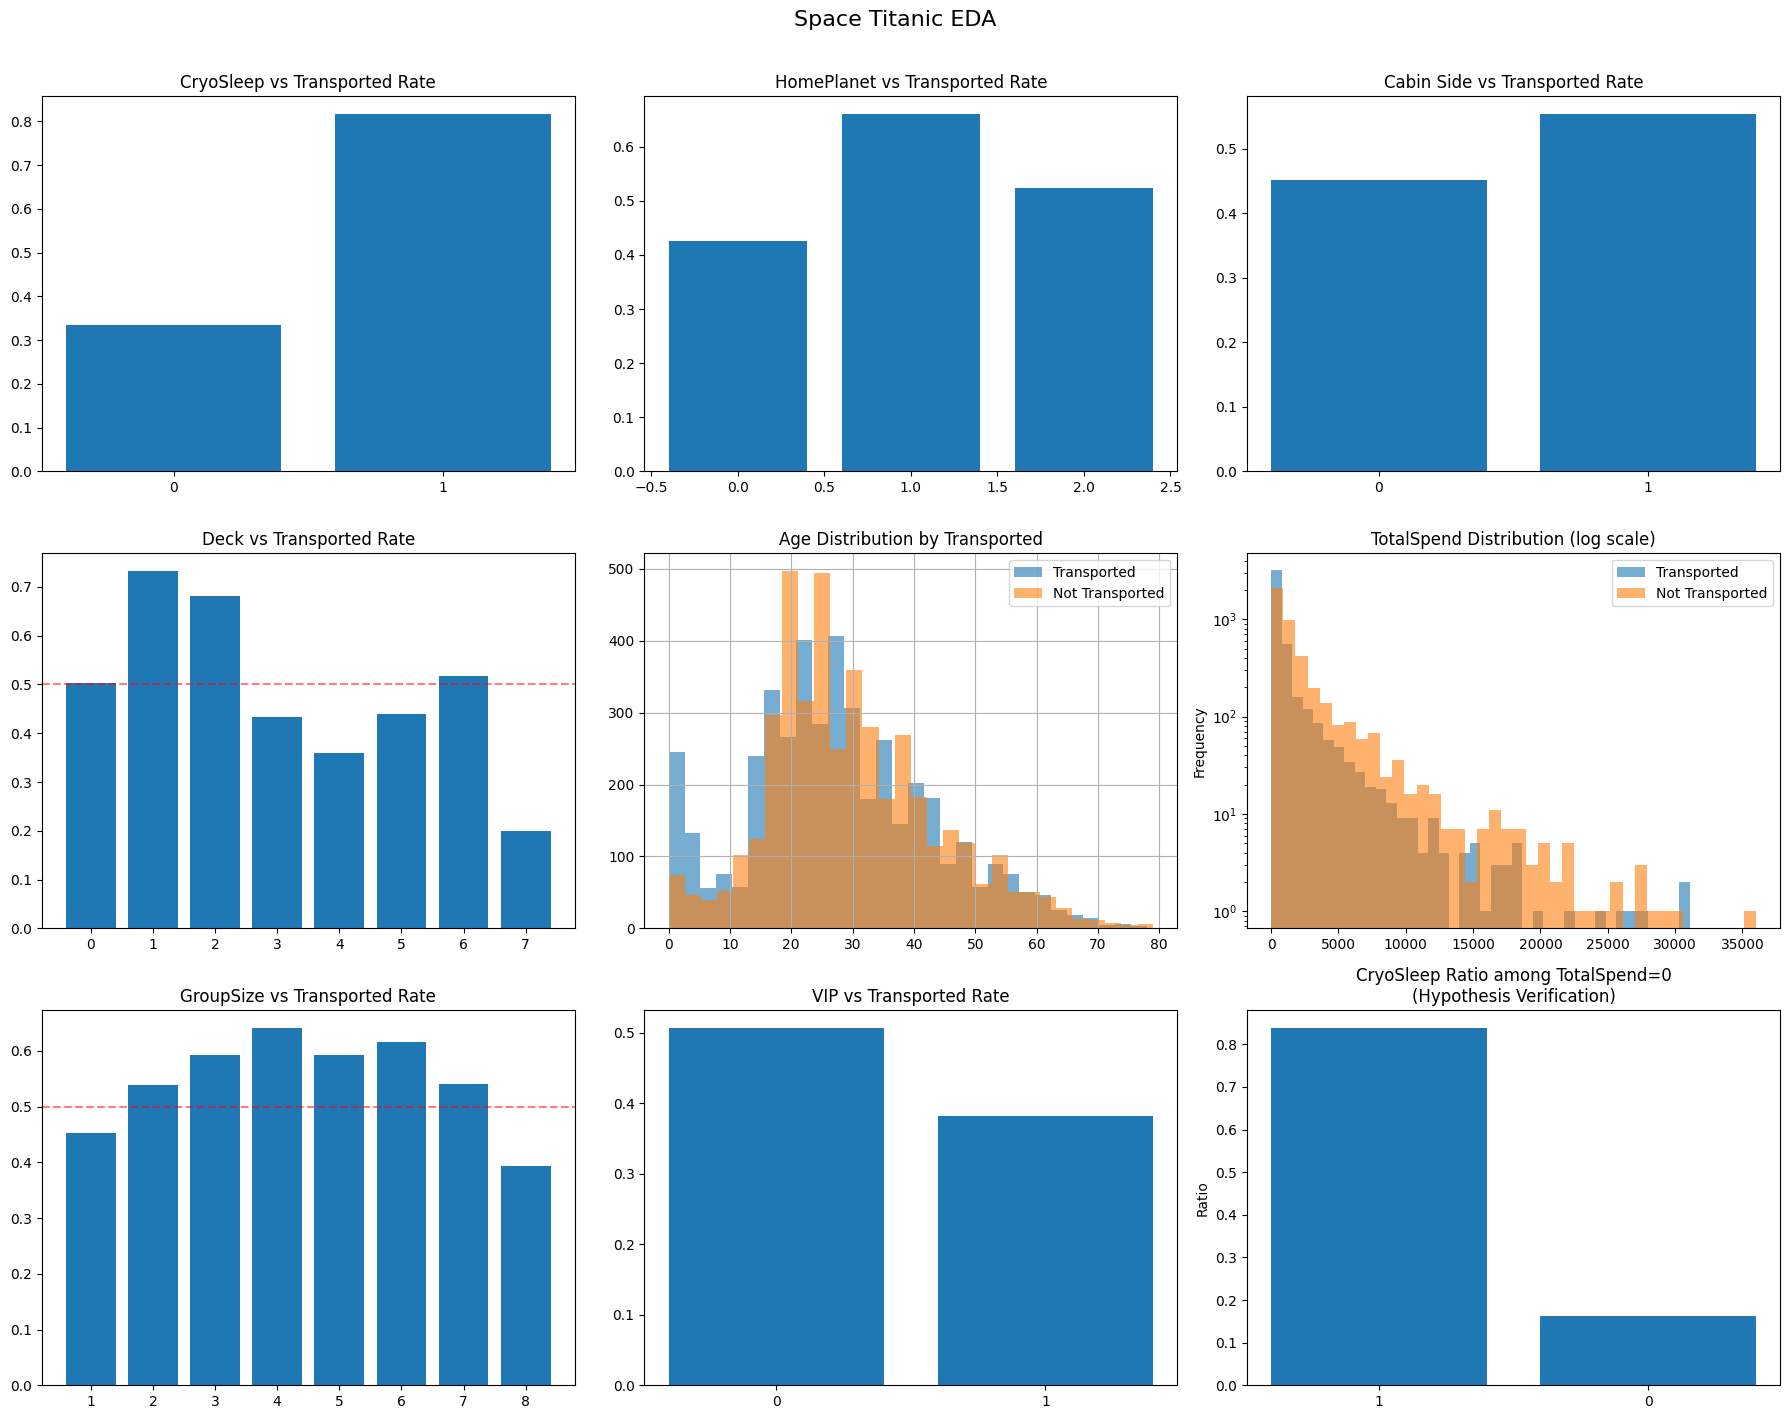

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Space Titanic EDA', fontsize=16, y=1.01)

cryo_trans = train.groupby('CryoSleep')['Transported'].mean().reset_index()
axes[0,0].bar(cryo_trans['CryoSleep'].astype(str), cryo_trans['Transported'])
axes[0,0].set_title('CryoSleep vs Transported Rate')

planet_trans = train.groupby('HomePlanet')['Transported'].mean().reset_index()
axes[0,1].bar(planet_trans['HomePlanet'], planet_trans['Transported'])
axes[0,1].set_title('HomePlanet vs Transported Rate')

side_trans = train.groupby('Side')['Transported'].mean().reset_index()
axes[0,2].bar(side_trans['Side'].astype(str), side_trans['Transported'])
axes[0,2].set_title('Cabin Side vs Transported Rate')

deck_trans = train.groupby('Deck')['Transported'].mean().reset_index()
axes[1,0].bar(deck_trans['Deck'].astype(str), deck_trans['Transported'])
axes[1,0].set_title('Deck vs Transported Rate')
axes[1,0].axhline(0.5, color='red', linestyle='--', alpha=0.5)

train[train['Transported']==True]['Age'].hist(ax=axes[1,1], alpha=0.6, bins=30, label='Transported')
train[train['Transported']==False]['Age'].hist(ax=axes[1,1], alpha=0.6, bins=30, label='Not Transported')
axes[1,1].set_title('Age Distribution by Transported')
axes[1,1].legend()

train[train['Transported']==True]['TotalSpend'].apply(lambda x: x+1).plot(kind='hist', ax=axes[1,2], alpha=0.6, bins=40, label='Transported', log=True)
train[train['Transported']==False]['TotalSpend'].apply(lambda x: x+1).plot(kind='hist', ax=axes[1,2], alpha=0.6, bins=40, label='Not Transported', log=True)
axes[1,2].set_title('TotalSpend Distribution (log scale)')
axes[1,2].legend()

group_trans = train.groupby('GroupSize')['Transported'].mean().reset_index()
axes[2,0].bar(group_trans['GroupSize'].astype(str), group_trans['Transported'])
axes[2,0].set_title('GroupSize vs Transported Rate')
axes[2,0].axhline(0.5, color='red', linestyle='--', alpha=0.5)

vip_trans = train.groupby('VIP')['Transported'].mean().reset_index()
axes[2,1].bar(vip_trans['VIP'].astype(str), vip_trans['Transported'])
axes[2,1].set_title('VIP vs Transported Rate')

zero_spend = train[train['TotalSpend'] == 0]
cryo_ratio = zero_spend['CryoSleep'].value_counts(normalize=True).reset_index()
axes[2,2].bar(cryo_ratio['CryoSleep'].astype(str), cryo_ratio['proportion'])
axes[2,2].set_title('CryoSleep Ratio among TotalSpend=0\n(Hypothesis Verification)')
axes[2,2].set_ylabel('Ratio')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
import pandas as pd
feat_imp = pd.Series(
    xgb_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
print(feat_imp.head())

HasSpend          0.629768
CryoSleep         0.062545
HomePlanet        0.031857
SpendPerPerson    0.026404
VRDeckRatio       0.022186
dtype: float32


Space Titanic — 분석 보고서
개요
본 분석은 Kaggle Space Titanic 대회 데이터를 기반으로, 우주선 타이타닉 사고 당시 승객이 다른 차원으로 이송되었는지 여부를 예측하는 이진 분류 문제다. 복구된 승객 기록 8,693건을 활용하여 데이터 전처리, 탐색적 분석, 모델 학습을 수행하였다.

목차
데이터 구조 파악
전처리 전략 및 논리적 근거
EDA 시각화 및 인사이트
모델 학습 및 결과
Summary
회고
Reference
1. 데이터 구조 파악
컬럼	설명	타입
PassengerId	그룹번호_개인번호 형식	object
HomePlanet	출발 행성 (Earth / Europa / Mars)	object
CryoSleep	냉동 수면 여부	bool
Cabin	갑판/번호/방향	object
Destination	목적지 행성	object
Age	나이	float
VIP	VIP 여부	bool
RoomService ~ VRDeck	5개 소비 항목	float
Transported	이송 여부 (TARGET)	bool
결측치 현황: PassengerId, Transported 제외 전 컬럼에 약 180~217건씩 존재.

2. 전처리 전략 및 논리적 근거
Phase 1 — CryoSleep × 소비항목 (단방향 확정)
냉동 수면 중인 승객은 객실에 격리되므로 어떠한 소비도 불가능하다. 이 관계는 단방향으로만 성립한다.


CryoSleep = True  →  소비 결측 = 0       (확실)
소비 > 0          →  CryoSleep = False   (확실)
소비 = 0          →  CryoSleep 결측 유지  (불확실, 건드리지 않음)
소비=0을 냉동=True로 단순 대입하지 않은 근거: EDA 결과 지출=0인 승객 3,653명 중 16.2%(약 592명)는 실제로 냉동 상태가 아니었다. 이 승객들은 식량을 직접 지참했거나, 소비를 하지 않는 종족이거나, 13세 미만 영유아일 가능성이 있다. 단순 대입 시 592명의 데이터가 오염된다.

Phase 2 — 그룹 기반 HomePlanet · Cabin 채우기
PassengerId 앞 4자리는 동행 그룹을 나타낸다. 같은 그룹의 승객은 동일한 행성에서 함께 탑승했을 가능성이 압도적으로 높다. 이를 활용해 단순 전체 최빈값 대입이 아닌 그룹 내 다른 멤버의 값으로 우선 채웠다.

주의: train/test를 분리한 상태에서 그룹 연산을 수행하면 가족이 두 데이터셋에 쪼개진 경우 정보가 단절된다. 이를 방지하기 위해 train과 test를 병합한 뒤 처리하고 다시 분리하는 concat→처리→split 방식을 채택하였다.

Cabin은 Deck / CabinNum / Side로 분리하였으며, CabinNum은 숫자처럼 보이나 공간 식별자이므로 전체 median 대입을 금지하고 같은 Deck 내 median으로 채웠다.

Phase 3 — 나머지 독립 변수 통계 처리
Age: HomePlanet + GroupSize 조건별 median → 전체 median 순
VIP: 전체의 98% 이상이 False → False로 일괄 대입
CryoSleep 잔여: 그룹 내 멤버값 참조 → 전체 최빈값 순
소비 잔여: 소비 컬럼은 분포 자체가 0에 극도로 쏠려 있으므로 0으로 대입
TotalSpend: 모든 결측 처리 완료 후 최종 재계산
3. EDA 시각화 및 인사이트
핵심 인사이트
① CryoSleep이 가장 강력한 예측 변수

냉동 수면 승객의 이송 비율은 81.6%인 반면, 깨어있던 승객은 33.4%에 불과하다. 48%p의 격차는 다른 어떤 변수보다 압도적이다. 사고 당시 의식 여부가 이송 여부를 결정짓는 가장 직접적인 요인임을 시사한다.

② 출발 행성별 격차

Europa 출신 승객의 이송 비율은 68%로 Earth(43%), Mars(53%)보다 유의미하게 높다. 출발 행성이 단순한 탑승 위치가 아니라 승객의 사회적 계층이나 탑승 구역과 연결될 가능성이 있다.

③ Cabin 위치가 운명을 갈랐다

Deck B, C의 이송 비율: 70% 전후
Deck T의 이송 비율: 20%
Side S(우현) 55.3% vs Side P(좌현) 45.2%
우주선 내 물리적 위치가 이송 여부에 직접적인 영향을 미쳤음을 보여준다.

④ 핵심 가설 검증 — 소비=0 ≠ 냉동

지출=0인 승객 3,653명 중 16.2%는 냉동 상태가 아니었다. 이는 전처리 단계에서 소비=0을 냉동=True로 단순 대입하지 않은 결정이 올바른 선택이었음을 정량적으로 증명한다.

4. 모델 학습 및 결과
본 프로젝트에서는 RandomForest, XGBoost 두 가지 모델을 학습하고 앙상블을 적용하였다.

모델	검증 정확도
RandomForest	0.7976
XGBoost	0.8062
RF 50% + XGBoost 50% 앙상블	0.8051
최종 캐글 Public Score: 0.80266

XGBoost는 검증 정확도가 높았으나 단독 제출 시 과적합 현상이 나타났다. RandomForest와 균등 앙상블했을 때 실제 테스트 데이터에서 가장 안정적인 일반화 성능을 보였다.

Feature Importance 상위 5개 (XGBoost 기준)

피처	중요도
HasSpend	0.6298
CryoSleep	0.0625
HomePlanet	0.0319
SpendPerPerson	0.0264
VRDeckRatio	0.0222
소비 여부(HasSpend)가 압도적으로 높은 중요도를 보였으며, 이는 Phase 1에서 CryoSleep과 소비항목의 논리적 관계를 먼저 처리한 전처리 전략이 모델 성능에 직접적으로 기여했음을 의미한다.

5. Summary
전처리의 핵심은 논리적 단방향 규칙이다. CryoSleep과 소비항목의 관계는 P→Q는 참이나 Q→P는 거짓임을 명확히 하고 코드에 반영하였다.
그룹 기반 결측치 처리는 단순 통계 대입보다 현실 세계의 맥락을 반영한 연역적 접근으로, 데이터 품질을 높이는 핵심 전략이었다.
EDA를 통해 CryoSleep, Deck, HomePlanet이 Transported와 강한 연관성을 가짐을 확인하였다.
Feature Importance 분석 결과 HasSpend가 가장 중요한 변수로 나타났으며, 이는 전처리 설계가 모델 성능에 직접 기여했음을 보여준다.
6. 회고
처음에 소비=0인 경우를 냉동=True로 양방향 대입하려 했으나, 이것이 명제 논리의 기본 오류임을 분석 과정에서 발견하고 수정하였다. 또한 train/test를 분리한 상태에서 그룹 연산을 수행하는 실수를 범했는데, 이는 그룹이 두 데이터셋에 걸쳐 분리될 수 있다는 현실을 간과한 것이었다. 모델링 단계에서는 검증 정확도가 높은 모델이 실제 테스트에서 과적합되는 현상을 직접 경험하였고, 단순한 앙상블이 복잡한 단일 모델보다 일반화 성능이 높을 수 있음을 배웠다. 데이터를 다루기 전에 데이터가 가진 물리적 의미를 먼저 시뮬레이션하는 습관의 중요성을 배웠다.

7. Reference
Kaggle Space Titanic Competition: https://www.kaggle.com/competitions/spaceship-titanic
Pandas Documentation: https://pandas.pydata.org/docs/
Scikit-learn Documentation: https://scikit-learn.org/stable/
XGBoost Documentation: https://xgboost.readthedocs.io/